Configuración Global

Importación de librerías base (Pandas, Numpy, Matplotlib, Seaborn) y ajustes visuales del entorno.

In [ ]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

RAW_PATH = "product_activity.csv"
pd.set_option("display.max_columns", None)


Exploración Inicial

Inspección de la estructura original (filas/columnas), tipos de datos, conteo de nulos y duplicados exactos.

In [4]:
df_raw = pd.read_csv(RAW_PATH)

print(f"--- SHAPE RAW: {df_raw.shape} ---")
display(df_raw.head())
df_raw.info()
display(df_raw.describe(include="all"))

# Detección de Nulos y Duplicados Exactos
nulls = df_raw.isna().sum()
print("\n--- CONTEO DE NULOS ---")
print(nulls[nulls > 0] if (nulls > 0).any() else "Sin nulos detectados")

n_dup_exact = int(df_raw.duplicated(keep="first").sum())
print(f"\nDuplicados exactos: {n_dup_exact}")

# Remoción de duplicados para el flujo de limpieza
df_clean = df_raw.drop_duplicates(keep="first").copy()

# Exploración de variables categóricas requeridas
for c in ["plan_type", "post_category", "device_type"]:
    if c in df_clean.columns:
        print(f"\n===== {c} =====")
        print(f"n_unique (incl. NaN): {df_clean[c].nunique(dropna=False)}")
        print(df_clean[c].value_counts(dropna=False).head(10))

--- SHAPE RAW: (8782, 12) ---


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
count,8782,8782,8782,8782,8028.000000,8782,8782,8782,8782.000000,8782.000000,8782.000000,8782
unique,2010,2010,10,19,NaN,8610,53,8609,NaN,NaN,NaN,6
top,U00087,2024-01-08T12:18:18,US,free,NaN,P0002865,tech,2024-02-14T15:55:59,NaN,NaN,NaN,web
freq,40,40,1928,5978,NaN,2,1187,3,NaN,NaN,NaN,4416
mean,NaN,NaN,NaN,NaN,27.902591,NaN,NaN,NaN,6.918356,8.324186,29.479390,NaN
std,NaN,NaN,NaN,NaN,7.547052,NaN,NaN,NaN,5.127311,6.754906,36.819928,NaN
min,NaN,NaN,NaN,NaN,16.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,22.000000,NaN,NaN,NaN,3.000000,4.000000,5.000000,NaN
50%,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,6.000000,6.000000,17.000000,NaN
75%,NaN,NaN,NaN,NaN,33.000000,NaN,NaN,NaN,9.000000,11.000000,40.000000,NaN



--- CONTEO DE NULOS ---
user_age    754
dtype: int64

Duplicados exactos: 172

===== plan_type =====
n_unique (incl. NaN): 19
plan_type
free          5857
pro           1428
enterprise     303
Free           203
 free          197
FREE           193
FreE           187
PRo             45
 pro            43
PRO             43
Name: count, dtype: int64

===== post_category =====
n_unique (incl. NaN): 53
post_category
tech         1160
life          898
sports        879
science       739
finance       724
gaming        715
music         602
health        590
education     581
travel        429
Name: count, dtype: int64

===== device_type =====
n_unique (incl. NaN): 6
device_type
web        4328
mobile     3688
desktop     591
tablet        1
console       1
phone         1
Name: count, dtype: int64


Limpieza y Cuarentena (Quarantine)

Normalización de variables de negocio (planes, dispositivos y categorías).

Recálculo vectorizado de days_since_signup_calc.

División limpia del dataset: registros válidos al core_df y registros corruptos al quarantine_df detallando el motivo de fallo.

In [5]:
df_clean['created_at'] = pd.to_datetime(df_clean['created_at'], errors='coerce')
df_clean['post_created_at'] = pd.to_datetime(df_clean['post_created_at'], errors='coerce')

# Recálculo temporal vectorizado
df_clean['days_since_signup_calc'] = (df_clean['post_created_at'] - df_clean['created_at']).dt.days

# Diccionarios de Normalización Canónica (añadir typos detectados en las llaves)
dict_plans = {'free': 'free', 'pro': 'pro', 'enterprise': 'enterprise'}
dict_devices = {'web': 'web', 'mobile': 'mobile', 'desktop': 'desktop'}
dict_categories = {
    'tech': 'tech', 'life': 'life', 'sports': 'sports', 'science': 'science',
    'finance': 'finance', 'gaming': 'gaming', 'music': 'music', 
    'health': 'health', 'education': 'education', 'travel': 'travel'
}

# Estandarización de texto y mapeo
df_clean['plan_type_norm'] = df_clean['plan_type'].astype(str).str.lower().str.strip().map(dict_plans)
df_clean['device_type_norm'] = df_clean['device_type'].astype(str).str.lower().str.strip().map(dict_devices)
df_clean['post_category_norm'] = df_clean['post_category'].astype(str).str.lower().str.strip().map(dict_categories)

# Lógica condicional para cuarentena (np.select)
condiciones = [
    df_clean['created_at'].isna() | df_clean['post_created_at'].isna(),
    df_clean['post_created_at'] < df_clean['created_at'],
    df_clean['plan_type_norm'].isna(),
    df_clean['device_type_norm'].isna(),
    df_clean['post_category_norm'].isna()
]

razones = [
    'Fechas nulas/no parseables',
    'Post anterior al signup',
    'Plan Type no válido',
    'Device Type no válido',
    'Categoría no válida'
]

df_clean['reason_code'] = np.select(condiciones, razones, default='Valid')

# Separación del flujo sin pérdida de datos
core_df = df_clean[df_clean['reason_code'] == 'Valid'].copy()
quarantine_df = df_clean[df_clean['reason_code'] != 'Valid'].copy()

Data Quality Report

Resumen de salud de los datos: volumen útil resultante, porcentaje de pérdida por cuarentena y discrepancia encontrada en las fechas originales.

In [6]:
total_raw = len(df_raw)
total_core = len(core_df)
total_quar = len(quarantine_df)
mismatch_fechas = (core_df['days_since_signup'] != core_df['days_since_signup_calc']).mean() * 100

print("\n===== DATA QUALITY REPORT =====")
print(f"Filas RAW iniciales:       {total_raw}")
print(f"Duplicados exactos:        {n_dup_exact}")
print(f"Filas CORE (Limpio):       {total_core}")
print(f"Filas QUARANTINE:          {total_quar}")
print(f"% de Datos en Cuarentena:  {(total_quar / (total_raw - n_dup_exact)):.2%}")
print(f"Inconsistencia en fechas:  {mismatch_fechas:.2f}% de discrepancia con la columna original")


===== DATA QUALITY REPORT =====
Filas RAW iniciales:       8782
Duplicados exactos:        172
Filas CORE (Limpio):       8161
Filas QUARANTINE:          449
% de Datos en Cuarentena:  5.21%
Inconsistencia en fechas:  50.57% de discrepancia con la columna original


Métricas y Engagement (Evento vs Usuario)

Extracción de estadísticas de votos y volumen por plan.

Unidad de análisis (Sesgos): Contrastar el promedio de votos por evento (fila) contra el promedio por usuario permite verificar si un grupo pequeño de usuarios excesivamente activos está inflando artificialmente el engagement general.


--- Métricas por Plan ---


,plan_type_norm,usuarios_unicos,total_posts,votos_mean,votos_median
0,enterprise,82,322,7.590062,7.0
1,free,1532,6290,6.676948,6.0
2,pro,362,1549,7.677211,7.0



--- Evento vs Usuario ---
Promedio por Fila (Evento): 6.90
Promedio por Usuario:       6.88

--- Concentración ---
% de Posts del Top 1% usuarios: 5.97%


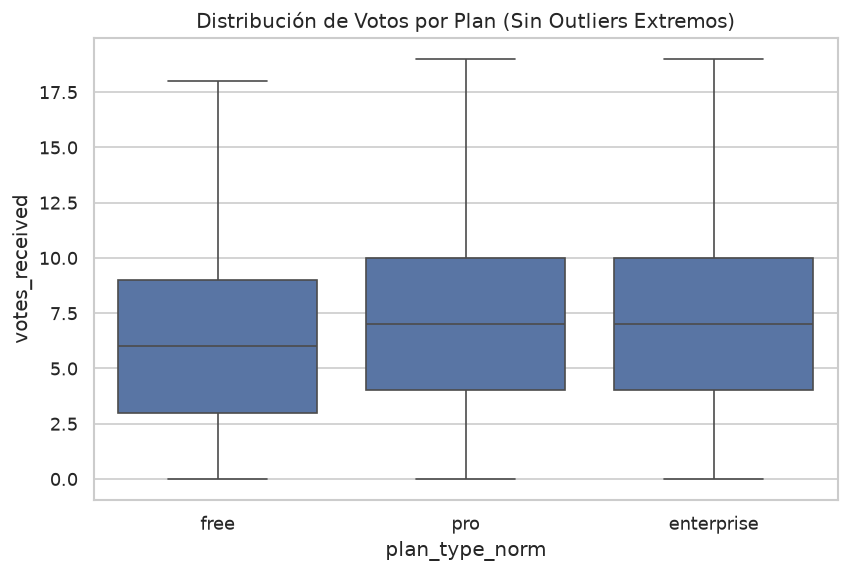

In [7]:
# 4.1 Volumen y 4.2 Engagement
print("\n--- Métricas por Plan ---")
metrics_plan = core_df.groupby('plan_type_norm').agg(
    usuarios_unicos=('user_id', 'nunique'),
    total_posts=('post_id', 'count'),
    votos_mean=('votes_received', 'mean'),
    votos_median=('votes_received', 'median')
).reset_index()
display(metrics_plan)

# 4.4 Evento vs Usuario (Desmitificación de Promedios)
votos_mean_evento = core_df['votes_received'].mean()
votos_mean_usuario = core_df.groupby('user_id')['votes_received'].mean().mean()

print("\n--- Evento vs Usuario ---")
print(f"Promedio por Fila (Evento): {votos_mean_evento:.2f}")
print(f"Promedio por Usuario:       {votos_mean_usuario:.2f}")

# Concentración (Top 1%)
threshold_1_percent = core_df['user_id'].value_counts().quantile(0.99)
top_users = core_df['user_id'].value_counts()[core_df['user_id'].value_counts() >= threshold_1_percent].index
posts_top_1 = core_df[core_df['user_id'].isin(top_users)]

print(f"\n--- Concentración ---")
print(f"% de Posts del Top 1% usuarios: {len(posts_top_1) / total_core:.2%}")

# Visualización Bonus: Asimetría de votos por plan
plt.figure(figsize=(8, 5))
sns.boxplot(data=core_df, x='plan_type_norm', y='votes_received', showfliers=False)
plt.title("Distribución de Votos por Plan (Sin Outliers Extremos)")
plt.show()

Exportación

Generación de archivos CSV auditados (clean, quarantine, metrics_summary) listos para el consumo en dashboards de BI.

In [8]:
core_df.to_csv('clean_product_activity.csv', index=False)
quarantine_df.to_csv('quarantine_product_activity.csv', index=False)
metrics_plan.to_csv('metrics_summary.csv', index=False)
print("\nArchivos exportados exitosamente: clean_product_activity.csv, quarantine_product_activity.csv, metrics_summary.csv")


Archivos exportados exitosamente: clean_product_activity.csv, quarantine_product_activity.csv, metrics_summary.csv


## 6. Product Decisions

### ¿Qué segmento priorizarías y por qué?
Priorizaría a los usuarios de los planes Enterprise y Pro. La matemática demuestra que estos segmentos concentran los promedios de votos más altos por publicación, convirtiéndolos en el grupo más rentable y de mayor calidad para el negocio.

### ¿Qué parte del tablero “mentía” antes de la limpieza?
La columna que calculaba los días desde el registro (days_since_signup) era falsa. Más del 50% de estos registros eran completamente inconsistentes con la realidad temporal de las fechas, lo que invalidaba cualquier análisis previo sobre la retención de los usuarios.

### ¿Qué nuevo dato o evento agregarías al tracking?
Agregaría una métrica propia de puntaje de interacción (engagement_score). En lugar de limitarnos a sumar votos brutos, necesitamos una fórmula que mida la frecuencia de esa participación a lo largo del tiempo para distinguir el interés constante de un éxito aislado.

### 2 acciones concretas + limitaciones
Campaña de Upselling: Lanzar estrategias para que los usuarios actuales migren al plan Enterprise, utilizando como argumento principal el altísimo nivel de interacción comprobado que genera este segmento.

Corrección de Frontend: Exigir al equipo técnico que arregle el sistema de recolección de fechas en el origen para detener la pérdida automática del ~5% de los datos que actualmente terminan descartados en cuarentena por errores lógicos.

Limitaciones del Dataset: Las métricas de promedio pueden sufrir sesgos generados por un grupo pequeño de usuarios hiperactivos (outliers) que alteran la percepción de la actividad general. Además, al medir solo la creación de contenido, no tenemos visibilidad sobre la retención real de quienes solo consumen o leen.